In [ ]:
"""
LEGACY FILE, this is only for reference on classification
"""

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
IRELAND_PATH = "data/Dataset/Country-Wise Data/Ireland_dataset.csv"
CHINA_PATH   = "data/Dataset/Country-Wise Data/China_dataset.csv"
MODEL_PATH   = "wqi_model.keras"
SCALER_PATH  = "scaler.joblib"
LE_PATH      = "label_encoder.joblib"
TARGET       = "CCME_WQI"
FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]
FEATURE_SHORT = ["Ammonia", "BOD", "DO", "Ortho-P", "pH", "Temp", "Nitrogen", "Nitrate"]
MINORITY      = ["Fair", "Marginal", "Poor"]
MAJORITY      = ["Excellent", "Good"]
CLASS_COLORS  = {
    "Excellent": "#2196F3", "Good": "#4CAF50",
    "Fair": "#FF9800", "Marginal": "#F44336", "Poor": "#9C27B0"
}


In [3]:
# ── 1. Load artifacts + data ─────────────────────────────────────────────────
model  = tf.keras.models.load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
le     = joblib.load(LE_PATH)

df_ire = pd.read_csv(IRELAND_PATH)   # training domain
df_chn = pd.read_csv(CHINA_PATH)     # transfer domain (no Poor)

print(f"Ireland: {df_ire.shape}  |  China: {df_chn.shape}")
print(f"\nIreland minority counts:")
print(df_ire[df_ire[TARGET].isin(MINORITY)][TARGET].value_counts())
print(f"\nChina minority counts:")
print(df_chn[df_chn[TARGET].isin(MINORITY)][TARGET].value_counts())

Ireland: (235019, 14)  |  China: (45997, 14)

Ireland minority counts:
CCME_WQI
Fair        1629
Poor        1423
Marginal     922
Name: count, dtype: int64

China minority counts:
CCME_WQI
Fair        336
Marginal    121
Name: count, dtype: int64


In [4]:
# ── 2. Run predictions on Ireland minority samples ───────────────────────────
df_min_ire = df_ire[df_ire[TARGET].isin(MINORITY)].copy()

X_min = scaler.transform(df_min_ire[FEATURES].values)
y_min = le.transform(df_min_ire[TARGET].values)

y_prob_min = model.predict(X_min, verbose=0)
y_pred_min = np.argmax(y_prob_min, axis=1)

df_min_ire["true_label"]  = le.inverse_transform(y_min)
df_min_ire["pred_label"]  = le.inverse_transform(y_pred_min)
df_min_ire["correct"]     = df_min_ire["true_label"] == df_min_ire["pred_label"]
df_min_ire["confidence"]  = y_prob_min.max(axis=1)

print("Minority-class accuracy per class (Ireland):")
for cls in MINORITY:
    sub = df_min_ire[df_min_ire["true_label"] == cls]
    acc = sub["correct"].mean()
    print(f"  {cls:10s}: {acc:.3f}  ({sub['correct'].sum()}/{len(sub)} correct)")

Minority-class accuracy per class (Ireland):
  Fair      : 0.982  (1599/1629 correct)
  Marginal  : 0.965  (890/922 correct)
  Poor      : 0.946  (1346/1423 correct)


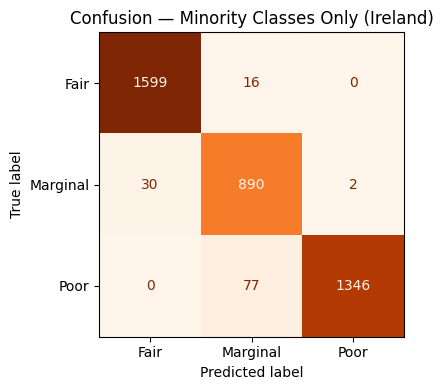

In [5]:
# ── 3. Plot 1 — Confusion matrix restricted to minority classes ──────────────
minority_labels = le.transform(MINORITY)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_min, y_pred_min, labels=minority_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=MINORITY)
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion — Minority Classes Only (Ireland)")
plt.tight_layout()
plt.savefig("minority_confusion.png", dpi=150)
plt.show()

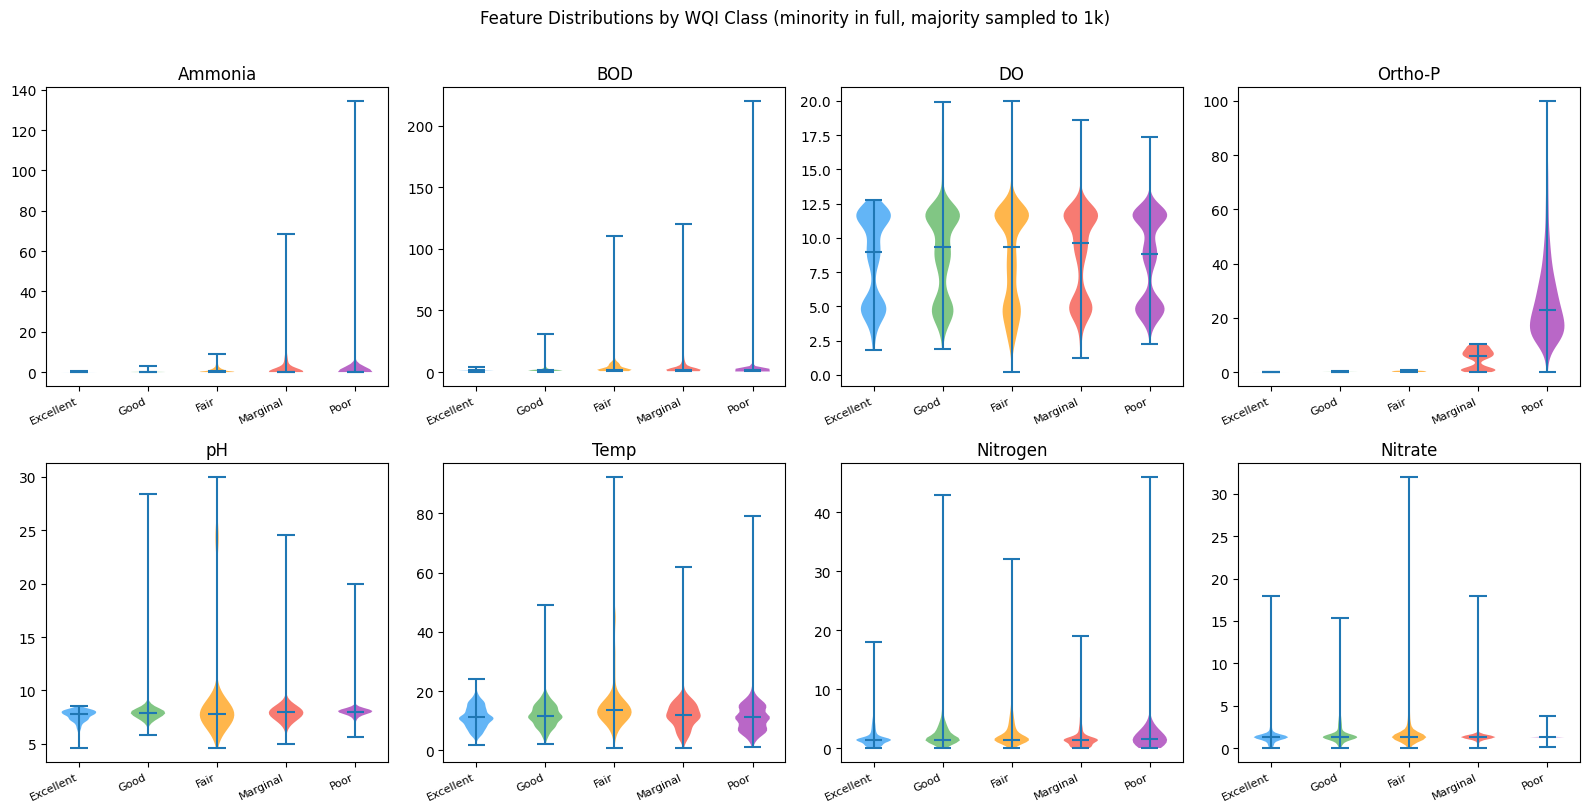

In [6]:
# ── 4. Plot 2 — Feature distributions: minority vs majority (violin) ──────────
N_SAMPLE = 1000
# Explicit per-class sampling avoids groupby().apply() pandas version issues
maj_frames = [
    df_ire[df_ire[TARGET] == cls].sample(
        min(len(df_ire[df_ire[TARGET] == cls]), N_SAMPLE), random_state=42
    )
    for cls in MAJORITY
]
df_plot = pd.concat([df_ire[df_ire[TARGET].isin(MINORITY)]] + maj_frames, ignore_index=True)
class_order = ["Excellent", "Good", "Fair", "Marginal", "Poor"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat, short in zip(axes.flat, FEATURES, FEATURE_SHORT):
    valid_data, valid_labels = [], []
    for cls in class_order:
        arr = df_plot[df_plot[TARGET] == cls][feat].dropna().values
        if len(arr) > 1:
            valid_data.append(arr)
            valid_labels.append(cls)

    if not valid_data:
        ax.set_title(short + " (no data)")
        continue

    parts = ax.violinplot(valid_data, showmedians=True)
    for pc, cls in zip(parts["bodies"], valid_labels):
        pc.set_facecolor(CLASS_COLORS[cls])
        pc.set_alpha(0.7)
    ax.set_xticks(range(1, len(valid_labels) + 1))
    ax.set_xticklabels(valid_labels, rotation=25, ha="right", fontsize=8)
    ax.set_title(short)

fig.suptitle("Feature Distributions by WQI Class (minority in full, majority sampled to 1k)", y=1.01)
plt.tight_layout()
plt.savefig("minority_feature_distributions.png", dpi=150)
plt.show()


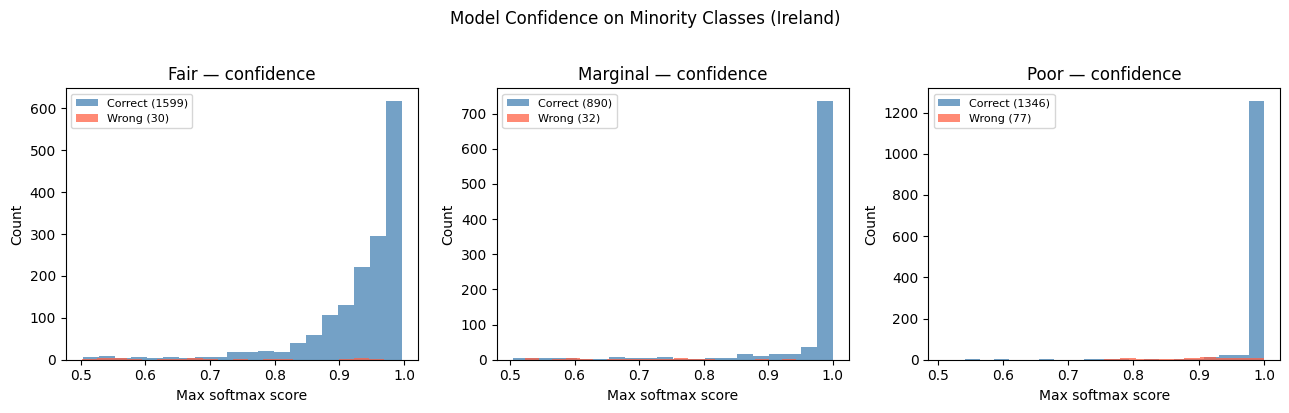

In [7]:
# ── 5. Plot 3 — Confidence distribution for minority classes ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, cls in zip(axes, MINORITY):
    sub = df_min_ire[df_min_ire["true_label"] == cls]
    ax.hist(sub[sub["correct"]]["confidence"],   bins=20, alpha=0.75,
            label=f"Correct ({sub['correct'].sum()})",   color="steelblue")
    ax.hist(sub[~sub["correct"]]["confidence"],  bins=20, alpha=0.75,
            label=f"Wrong ({(~sub['correct']).sum()})",   color="tomato")
    ax.set_title(f"{cls} — confidence")
    ax.set_xlabel("Max softmax score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Model Confidence on Minority Classes (Ireland)", y=1.02)
plt.tight_layout()
plt.savefig("minority_confidence.png", dpi=150)
plt.show()

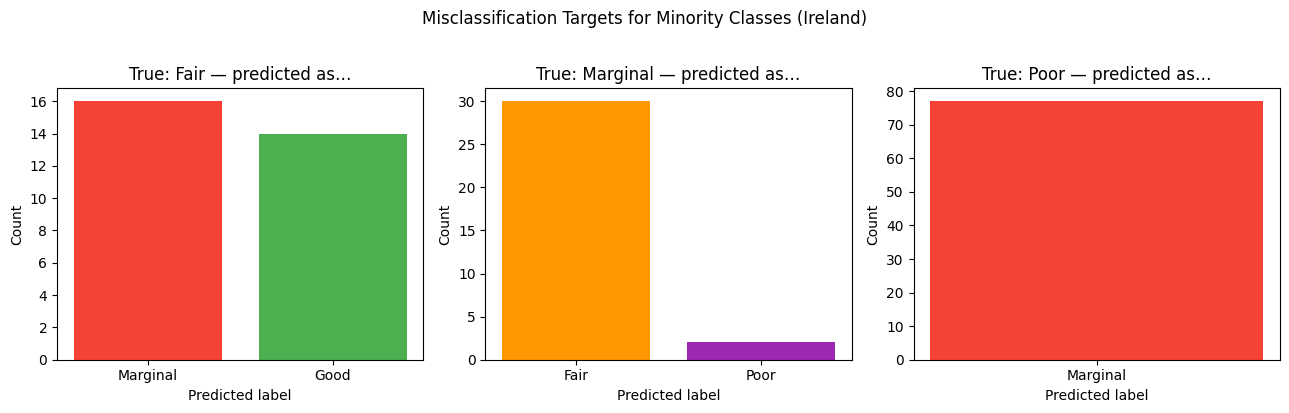

In [8]:
# ── 6. Plot 4 — What does the model predict instead? (misclassification breakdown)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cls in zip(axes, MINORITY):
    sub = df_min_ire[(df_min_ire["true_label"] == cls) & (~df_min_ire["correct"])]
    if len(sub) == 0:
        ax.set_title(f"{cls} — no errors")
        continue
    counts = sub["pred_label"].value_counts()
    colors = [CLASS_COLORS.get(c, "grey") for c in counts.index]
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"True: {cls} — predicted as…")
    ax.set_ylabel("Count")
    ax.set_xlabel("Predicted label")

fig.suptitle("Misclassification Targets for Minority Classes (Ireland)", y=1.02)
plt.tight_layout()
plt.savefig("minority_misclassification_targets.png", dpi=150)
plt.show()

PCA variance explained: 0.592


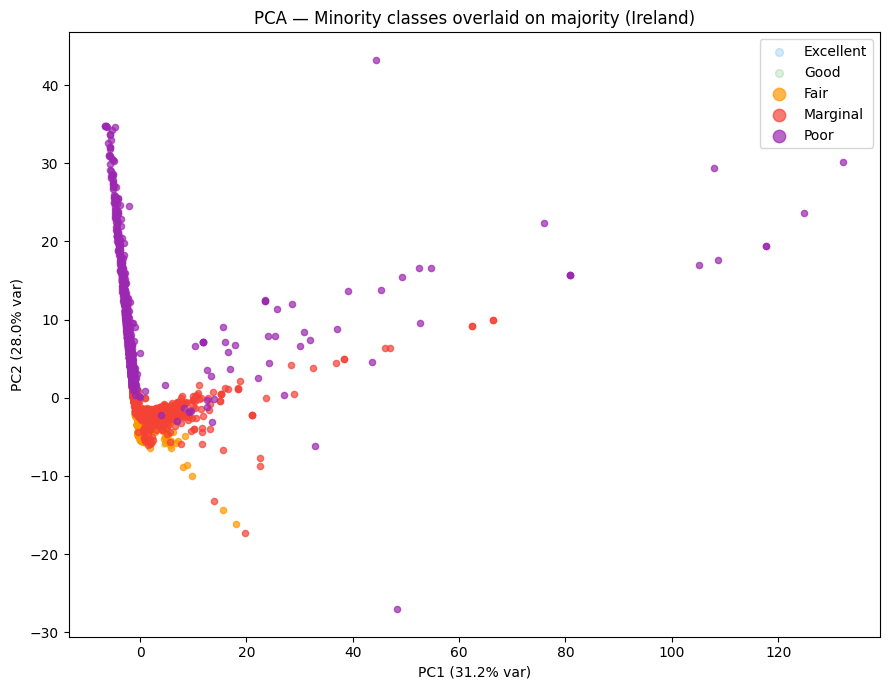

In [9]:
# ── 7. Plot 5 — PCA: all classes, minority highlighted ───────────────────────
maj_frames_pca = [
    df_ire[df_ire[TARGET] == cls].sample(
        min(len(df_ire[df_ire[TARGET] == cls]), 1500), random_state=42
    )
    for cls in MAJORITY
]
df_pca = pd.concat(
    [df_ire[df_ire[TARGET].isin(MINORITY)]] + maj_frames_pca, ignore_index=True
)

X_pca_raw = scaler.transform(df_pca[FEATURES].values)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_pca_raw)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(9, 7))
for cls in MAJORITY + MINORITY:
    mask = df_pca[TARGET].values == cls
    size   = 8  if cls in MAJORITY else 20
    alpha  = 0.2 if cls in MAJORITY else 0.7
    zorder = 1  if cls in MAJORITY else 3
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLASS_COLORS[cls], s=size, alpha=alpha,
               label=cls, zorder=zorder)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA — Minority classes overlaid on majority (Ireland)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("minority_pca.png", dpi=150)
plt.show()


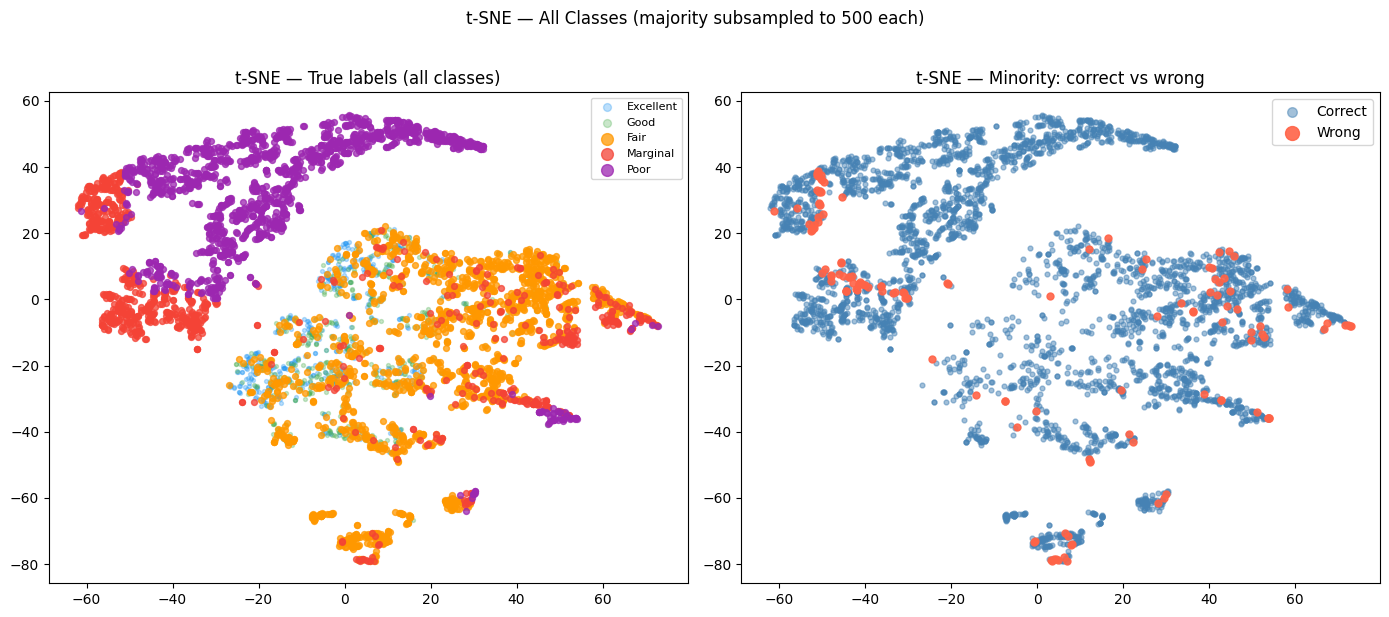

In [10]:
# ── 8. Plot 6 — t-SNE: minority + subsampled majority ────────────────────────
# Cap majority at 500 each so t-SNE stays fast (~5k points total)
N_TSNE_MAJ = 500
maj_frames_tsne = [
    df_ire[df_ire[TARGET] == cls].sample(
        min(len(df_ire[df_ire[TARGET] == cls]), N_TSNE_MAJ), random_state=42
    )
    for cls in MAJORITY
]
df_tsne = pd.concat(
    [df_ire[df_ire[TARGET].isin(MINORITY)]] + maj_frames_tsne, ignore_index=True
)

X_tsne_in = scaler.transform(df_tsne[FEATURES].values)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: coloured by true class (all 5)
for cls in MAJORITY + MINORITY:
    mask = df_tsne[TARGET].values == cls
    size  = 8  if cls in MAJORITY else 18
    alpha = 0.3 if cls in MAJORITY else 0.75
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=CLASS_COLORS[cls], s=size, alpha=alpha, label=cls)
axes[0].set_title("t-SNE — True labels (all classes)")
axes[0].legend(markerscale=2, fontsize=8)

# Right: minority only — correct (blue) vs wrong (red)
min_mask = df_tsne[TARGET].isin(MINORITY).values
y_tsne_true = le.transform(df_tsne[TARGET].values)
y_tsne_pred = np.argmax(model.predict(X_tsne_in, verbose=0), axis=1)
correct_mask = (y_tsne_true == y_tsne_pred) & min_mask
wrong_mask   = (y_tsne_true != y_tsne_pred) & min_mask

axes[1].scatter(X_tsne[min_mask & correct_mask, 0], X_tsne[min_mask & correct_mask, 1],
                c="steelblue", s=12, alpha=0.5, label="Correct")
axes[1].scatter(X_tsne[min_mask & wrong_mask,   0], X_tsne[min_mask & wrong_mask,   1],
                c="tomato",    s=25, alpha=0.9, label="Wrong", zorder=3)
axes[1].set_title("t-SNE — Minority: correct vs wrong")
axes[1].legend(markerscale=2)

fig.suptitle("t-SNE — All Classes (majority subsampled to 500 each)", y=1.02)
plt.tight_layout()
plt.savefig("minority_tsne.png", dpi=150)
plt.show()


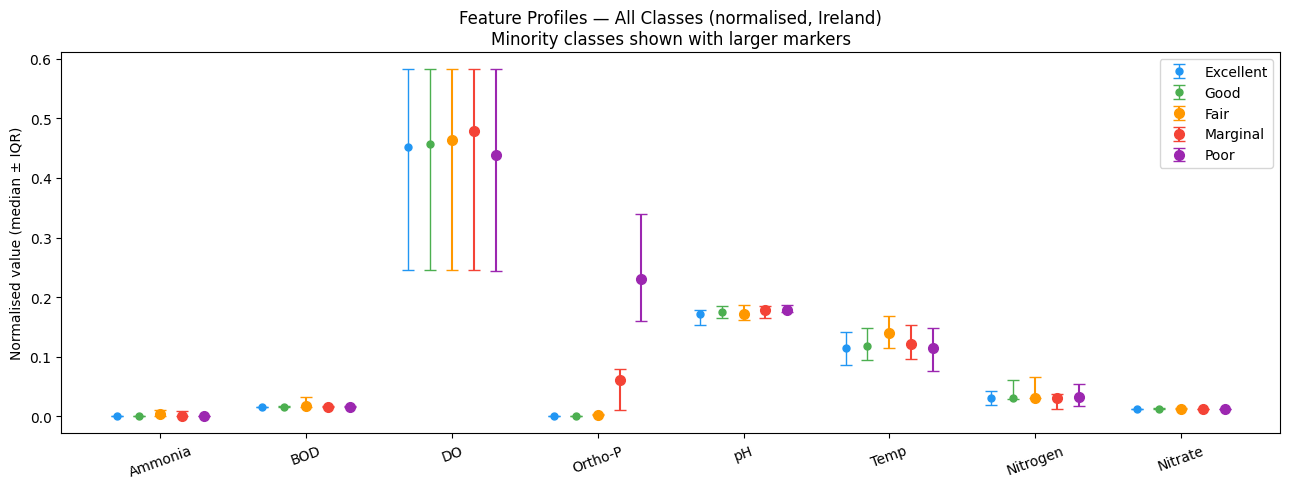

In [11]:
# ── 9. Plot 7 — Feature overlap: median ± IQR for all classes ────────────────
all_classes   = ["Excellent", "Good", "Fair", "Marginal", "Poor"]
feat_min = df_ire[FEATURES].min()
feat_max = df_ire[FEATURES].max()
norm = lambda s: (s - feat_min) / (feat_max - feat_min + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(FEATURES))
offsets = np.linspace(-0.3, 0.3, len(all_classes))

for offset, cls in zip(offsets, all_classes):
    sub = df_ire[df_ire[TARGET] == cls][FEATURES]
    med_n = norm(sub.median()).values
    lo_n  = norm(sub.quantile(0.25)).values
    hi_n  = norm(sub.quantile(0.75)).values
    lw    = 1.5 if cls in MINORITY else 1.0
    ms    = 7   if cls in MINORITY else 5
    ax.errorbar(x + offset, med_n,
                yerr=[med_n - lo_n, hi_n - med_n],
                fmt="o", capsize=4, label=cls,
                color=CLASS_COLORS[cls], linewidth=lw, markersize=ms)

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_SHORT, rotation=20)
ax.set_ylabel("Normalised value (median ± IQR)")
ax.set_title("Feature Profiles — All Classes (normalised, Ireland)\nMinority classes shown with larger markers")
ax.legend()
plt.tight_layout()
plt.savefig("minority_feature_profiles.png", dpi=150)
plt.show()
